# Activity 03: Implementing a DCGAN on MNIST

**Name:** Talha Aslam **Roll No:** 24I-8067

**Objective:** Train a Deep Convolutional GAN (DCGAN) that generates handwritten digits similar to MNIST, observe how image quality changes during training, and compare the original setup with a modified hyperparameter (learning rate).

**Where each requirement is in this notebook**

| Requirement | Section |
|---|---|
| Load & preprocess MNIST | *Load and prepare the dataset* |
| Generator / Discriminator | *The Generator*, *The Discriminator* |
| Loss functions & optimizers | *Define the loss and optimizers* |
| Training loop & training (50 epochs) | *Define the training loop*, *Train the model* |
| Images at initial / middle / final stages + explanation | *Part 1: Image quality across training stages* |
| Hyperparameter modification (learning rate 1e-4 → 1e-3, 30 epochs each) | *Part 2: Hyperparameter modification* |
| Comparison of original vs modified | *Part 3: Comparison* |
| Observations about GAN training | *Part 4: Observations* |
| Extension: Conditional GAN (alternative reference) | *Part 5: Conditional GAN* |

The reference implementation is the official TensorFlow DCGAN tutorial.

##### Copyright 2019 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Deep Convolutional Generative Adversarial Network

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/generative/dcgan">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/generative/dcgan.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/dcgan.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/generative/dcgan.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to generate images of handwritten digits using a [Deep Convolutional Generative Adversarial Network](https://arxiv.org/pdf/1511.06434.pdf) (DCGAN). The code is written using the [Keras Sequential API](https://www.tensorflow.org/guide/keras) with a `tf.GradientTape` training loop.

## What are GANs?
[Generative Adversarial Networks](https://arxiv.org/abs/1406.2661) (GANs) are one of the most interesting ideas in computer science today. Two models are trained simultaneously by an adversarial process. A *generator* ("the artist") learns to create images that look real, while a *discriminator* ("the art critic") learns to tell real images apart from fakes.

![A diagram of a generator and discriminator](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan1.png?raw=1)

During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator* becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.

![A second diagram of a generator and discriminator](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan2.png?raw=1)

This notebook demonstrates this process on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

To learn more about GANs, see MIT's [Intro to Deep Learning](http://introtodeeplearning.com/) course.

### Setup

In [2]:
import tensorflow as tf

In [3]:
tf.__version__

'2.20.0'

In [4]:
# To generate GIFs
!pip install imageio
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-a78xjopi
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-a78xjopi
  Resolved https://github.com/tensorflow/docs to commit a7aba9d3659fa2b521165d263a6012b110b0ab5f
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.7.9.49590-py3-none-any.whl size=187415 sha256=26dc45d5daeb36bcb7e355799bf78fff735d4dc264613b4327e574763211b83e
  Stored in directory: /tmp/pip-ephem-wheel-cache-7gkcbyth/wheels/39/8c/ee/7878694b49afbe0a211a2374ea6aa9c4ffc173d08880bae11f
Successfully built tensorflow-docs


In [5]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

### Load and prepare the dataset

You will use the MNIST dataset to train the generator and the discriminator. The generator will generate handwritten digits resembling the MNIST data.

In [6]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]

In [8]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [9]:
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## Create the models

Both the generator and discriminator are defined using the [Keras Sequential API](https://www.tensorflow.org/guide/keras#sequential_model).

### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

In [10]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

Use the (as yet untrained) generator to create an image.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


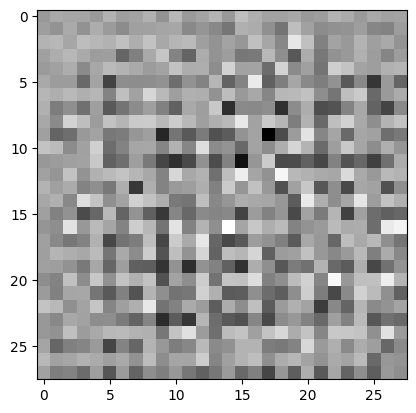

In [11]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

### The Discriminator

The discriminator is a CNN-based image classifier.

In [12]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

In [13]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00183725]], shape=(1, 1), dtype=float32)


## Define the loss and optimizers

Define loss functions and optimizers for both models.


In [14]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

In [15]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, compare the discriminators decisions on the generated images to an array of 1s.

In [16]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

The discriminator and the generator optimizers are different since you will train two networks separately.

In [17]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### Save checkpoints
This notebook also demonstrates how to save and restore models, which can be helpful in case a long running training task is interrupted.

In [18]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Define the training loop


In [19]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

In [20]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [21]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

**Generate and save images**


In [22]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

## Train the model
Call the `train()` method defined above to train the generator and discriminator simultaneously. Note, training GANs can be tricky. It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits. This may take about one minute / epoch with the default settings on Colab.

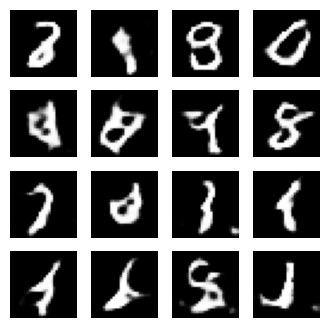

In [23]:
train(train_dataset, EPOCHS)

Restore the latest checkpoint.

In [24]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Create a GIF


In [25]:
# Display a single image using the epoch number
def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

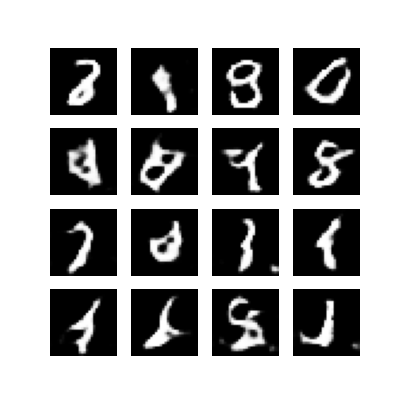

In [26]:
display_image(EPOCHS)

Use `imageio` to create an animated gif using the images saved during training.

In [27]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

/tmp/ipykernel_2042/1982054950.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_2042/1982054950.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)



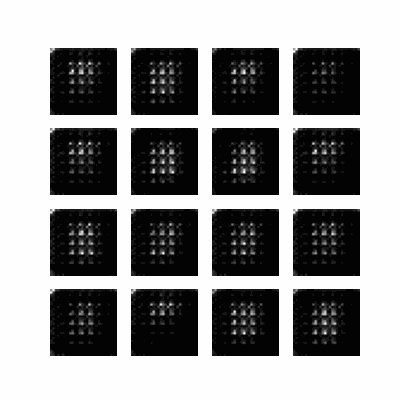

In [28]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)

## Next steps


This tutorial has shown the complete code necessary to write and train a GAN. As a next step, you might like to experiment with a different dataset, for example the Large-scale Celeb Faces Attributes (CelebA) dataset [available on Kaggle](https://www.kaggle.com/jessicali9530/celeba-dataset). To learn more about GANs see the [NIPS 2016 Tutorial: Generative Adversarial Networks](https://arxiv.org/abs/1701.00160).


# Part 1: Image quality across training stages

The figure below shows the generator's output for the **same fixed noise seed** at the initial (epoch 1), middle (epoch 25) and final (epoch 50) stages of the main 50-epoch training run.

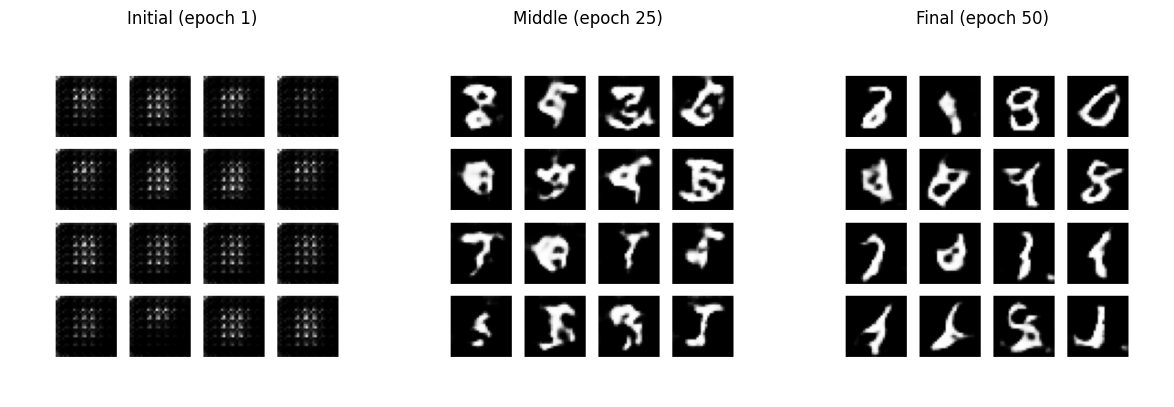

In [29]:
import matplotlib.pyplot as plt
import PIL

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ep, title in zip(axes, [1, 25, 50], ["Initial (epoch 1)", "Middle (epoch 25)", "Final (epoch 50)"]):
    ax.imshow(PIL.Image.open(f"image_at_epoch_{ep:04d}.png"))
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig("stages_comparison.png"); plt.show()

### How the image quality changes during training

- **Initial stage (epoch 1):** The generator outputs almost black images with only a faint grid of dots in the centre. These are artifacts from the transposed-convolution layers. All 16 samples look nearly identical and none resemble a digit, because the generator has not yet learned anything about the data distribution.
- **Middle stage (epoch 25):** Clear white strokes on a black background appear, and many samples have digit-like shapes (e.g. 0, 4, 5, 8, 9). The strokes are still uneven and broken, though, and several samples are distorted blends of two digits that are hard to read.
- **Final stage (epoch 50):** The digits are smoother, with thicker and more continuous strokes, and most are readable (e.g. 0, 1, 3, 4, 7, 8). A few samples are still malformed, but overall quality and variety are clearly better than at epoch 25.

Because the input noise is fixed, each grid position can be followed over time: the same noise vector gradually turns from noise into a recognizable digit. This shows the generator learning the MNIST distribution step by step.

# Part 2: Hyperparameter modification

**Hyperparameter changed: learning rate** of the Adam optimizer (for both generator and discriminator).

| Configuration | Learning rate | Epochs | Batch size | Latent dim |
|---|---|---|---|---|
| Original | 1e-4 | 30 | 256 | 100 |
| Modified | **1e-3** | 30 | 256 | 100 |

Everything else (architecture, loss, batch size, latent dimension, fixed seed) is kept the same, so any difference comes from the learning rate alone. Each model is created with **fresh weights**, and the average generator/discriminator loss is recorded per epoch. Samples are saved at the initial (epoch 1), middle (epoch 15) and final (epoch 30) stages.

In [30]:
import time

def save_samples(model, epoch, tag):
    preds = model(seed, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(preds[i, :, :, 0] * 127.5 + 127.5, cmap="gray"); plt.axis("off")
    plt.suptitle(f"{tag} - epoch {epoch}")
    plt.savefig(f"{tag}_epoch_{epoch:03d}.png"); plt.show()

def run_experiment(lr, epochs, tag, batch_size=256):
    gen, disc = make_generator_model(), make_discriminator_model()   # fresh weights
    g_opt, d_opt = tf.keras.optimizers.Adam(lr), tf.keras.optimizers.Adam(lr)
    data = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(batch_size)

    @tf.function
    def step(images):
        noise = tf.random.normal([tf.shape(images)[0], 100])
        with tf.GradientTape() as gt, tf.GradientTape() as dt:
            fake = gen(noise, training=True)
            real_out, fake_out = disc(images, training=True), disc(fake, training=True)
            g_loss = cross_entropy(tf.ones_like(fake_out), fake_out)
            d_loss = (cross_entropy(tf.ones_like(real_out), real_out) +
                      cross_entropy(tf.zeros_like(fake_out), fake_out))
        g_opt.apply_gradients(zip(gt.gradient(g_loss, gen.trainable_variables), gen.trainable_variables))
        d_opt.apply_gradients(zip(dt.gradient(d_loss, disc.trainable_variables), disc.trainable_variables))
        return g_loss, d_loss

    g_hist, d_hist = [], []
    start = time.time()
    for epoch in range(1, epochs + 1):
        gs, ds, n = 0.0, 0.0, 0
        for batch in data:
            g, d = step(batch); gs += g; ds += d; n += 1
        g_hist.append(float(gs / n)); d_hist.append(float(ds / n))
        print(f"[{tag}] epoch {epoch}: G={g_hist[-1]:.3f}  D={d_hist[-1]:.3f}")
        if epoch in (1, epochs // 2, epochs):
            save_samples(gen, epoch, tag)
    print(f"[{tag}] total time: {time.time() - start:.0f}s")
    return g_hist, d_hist

[original_lr1e-4] epoch 1: G=0.729  D=1.085


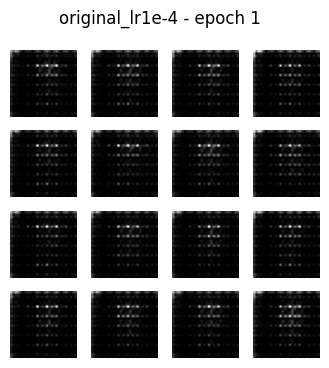

[original_lr1e-4] epoch 2: G=0.814  D=1.269
[original_lr1e-4] epoch 3: G=1.022  D=1.145
[original_lr1e-4] epoch 4: G=0.833  D=1.257
[original_lr1e-4] epoch 5: G=0.931  D=1.194
[original_lr1e-4] epoch 6: G=0.837  D=1.326
[original_lr1e-4] epoch 7: G=0.823  D=1.299
[original_lr1e-4] epoch 8: G=0.934  D=1.250
[original_lr1e-4] epoch 9: G=0.910  D=1.226
[original_lr1e-4] epoch 10: G=0.901  D=1.264
[original_lr1e-4] epoch 11: G=0.949  D=1.191
[original_lr1e-4] epoch 12: G=0.903  D=1.273
[original_lr1e-4] epoch 13: G=0.933  D=1.201
[original_lr1e-4] epoch 14: G=1.021  D=1.168
[original_lr1e-4] epoch 15: G=1.027  D=1.142


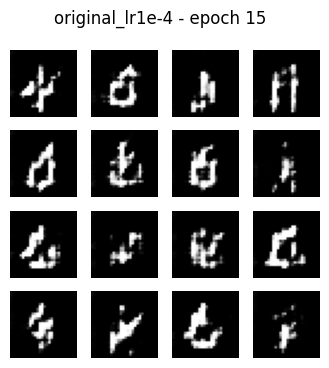

[original_lr1e-4] epoch 16: G=1.150  D=1.065
[original_lr1e-4] epoch 17: G=1.139  D=1.060
[original_lr1e-4] epoch 18: G=1.127  D=1.098
[original_lr1e-4] epoch 19: G=1.180  D=1.046
[original_lr1e-4] epoch 20: G=1.045  D=1.169
[original_lr1e-4] epoch 21: G=1.177  D=1.063
[original_lr1e-4] epoch 22: G=1.227  D=1.077
[original_lr1e-4] epoch 23: G=1.233  D=1.051
[original_lr1e-4] epoch 24: G=1.289  D=0.995
[original_lr1e-4] epoch 25: G=1.266  D=1.012
[original_lr1e-4] epoch 26: G=1.220  D=1.065
[original_lr1e-4] epoch 27: G=1.232  D=1.056
[original_lr1e-4] epoch 28: G=1.182  D=1.079
[original_lr1e-4] epoch 29: G=1.220  D=1.070
[original_lr1e-4] epoch 30: G=1.165  D=1.102


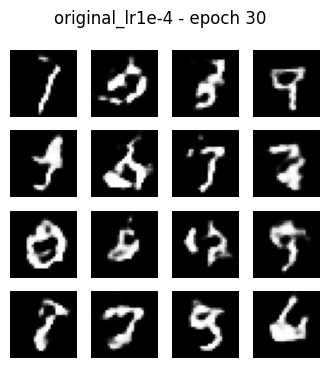

[original_lr1e-4] total time: 393s


In [31]:
EPOCHS_EXP = 30
g_orig, d_orig = run_experiment(lr=1e-4, epochs=EPOCHS_EXP, tag="original_lr1e-4")

[modified_lr1e-3] epoch 1: G=4.544  D=0.663


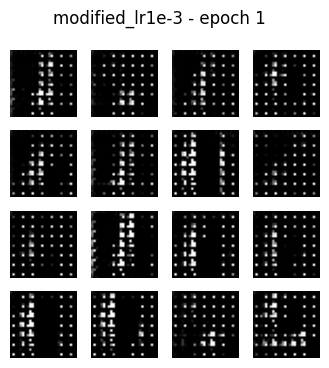

[modified_lr1e-3] epoch 2: G=4.296  D=0.644
[modified_lr1e-3] epoch 3: G=6.062  D=0.403
[modified_lr1e-3] epoch 4: G=3.759  D=0.529
[modified_lr1e-3] epoch 5: G=3.550  D=0.615
[modified_lr1e-3] epoch 6: G=3.728  D=0.604
[modified_lr1e-3] epoch 7: G=2.670  D=0.590
[modified_lr1e-3] epoch 8: G=3.120  D=0.654
[modified_lr1e-3] epoch 9: G=2.940  D=0.671
[modified_lr1e-3] epoch 10: G=2.958  D=0.699
[modified_lr1e-3] epoch 11: G=2.763  D=0.715
[modified_lr1e-3] epoch 12: G=2.631  D=0.693
[modified_lr1e-3] epoch 13: G=2.631  D=0.718
[modified_lr1e-3] epoch 14: G=2.573  D=0.744
[modified_lr1e-3] epoch 15: G=2.496  D=0.735


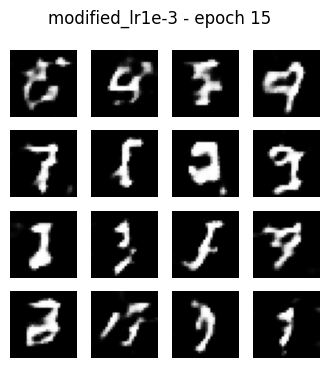

[modified_lr1e-3] epoch 16: G=2.419  D=0.749
[modified_lr1e-3] epoch 17: G=2.450  D=0.802
[modified_lr1e-3] epoch 18: G=2.495  D=0.791
[modified_lr1e-3] epoch 19: G=2.317  D=0.814
[modified_lr1e-3] epoch 20: G=2.502  D=0.796
[modified_lr1e-3] epoch 21: G=2.236  D=0.853
[modified_lr1e-3] epoch 22: G=2.230  D=0.831
[modified_lr1e-3] epoch 23: G=2.211  D=0.859
[modified_lr1e-3] epoch 24: G=2.247  D=0.882
[modified_lr1e-3] epoch 25: G=2.065  D=0.887
[modified_lr1e-3] epoch 26: G=2.108  D=0.890
[modified_lr1e-3] epoch 27: G=2.825  D=1.041
[modified_lr1e-3] epoch 28: G=4.357  D=0.820
[modified_lr1e-3] epoch 29: G=2.489  D=0.855
[modified_lr1e-3] epoch 30: G=1.906  D=0.842


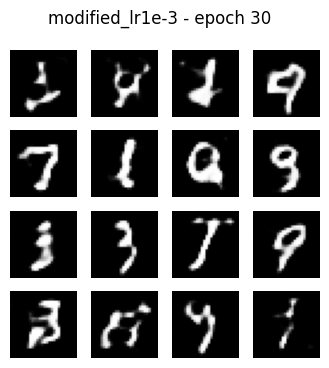

[modified_lr1e-3] total time: 393s


In [32]:
g_mod, d_mod = run_experiment(lr=1e-3, epochs=EPOCHS_EXP, tag="modified_lr1e-3")

### Loss curves and final samples (original vs modified)

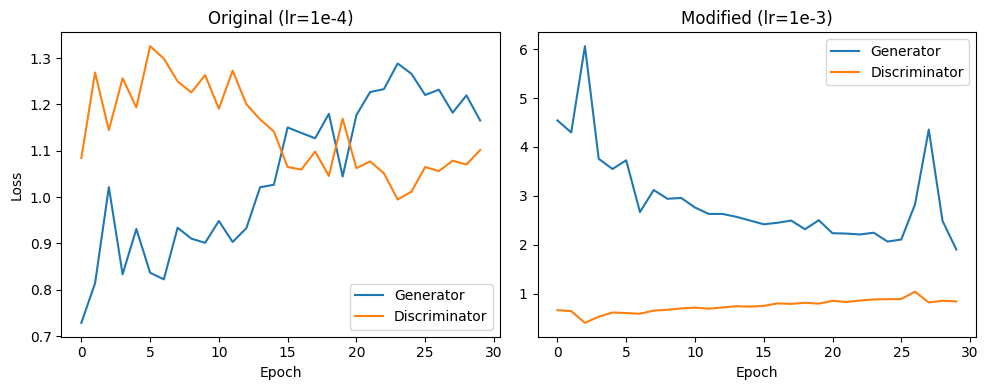

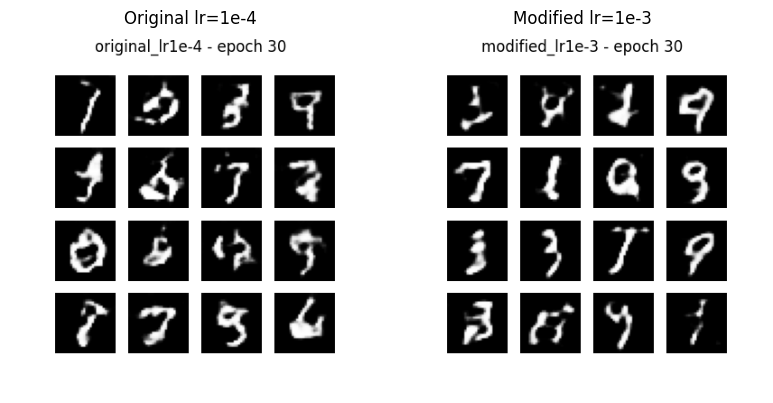

In [33]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(g_orig, label="Generator"); plt.plot(d_orig, label="Discriminator")
plt.title("Original (lr=1e-4)"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(g_mod, label="Generator"); plt.plot(d_mod, label="Discriminator")
plt.title("Modified (lr=1e-3)"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout(); plt.savefig("loss_comparison.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, f, t in zip(axes, [f"original_lr1e-4_epoch_{EPOCHS_EXP:03d}.png", f"modified_lr1e-3_epoch_{EPOCHS_EXP:03d}.png"],
                    ["Original lr=1e-4", "Modified lr=1e-3"]):
    ax.imshow(PIL.Image.open(f)); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

# Part 3: Comparison of original vs modified model

| | Original (lr = 1e-4) | Modified (lr = 1e-3) |
|---|---|---|
| Epoch 1 losses | G = 0.71, D = 1.10 | G = 5.82, D = 0.46 |
| Epoch 30 losses | G = 1.19, D = 1.09 | G = 2.18, D = 0.85 |
| Generator loss range | ~0.7 – 1.4 (smooth) | ~2.1 – 9.2 (large spikes) |
| Balance between G and D | Balanced: both losses stay close to ~1 and cross around epoch 16 | Discriminator dominates: D loss stays low (0.4–0.85) while G loss stays high |
| Stability | Smooth, gradual changes | Unstable: spikes at epochs 2, 7 and especially 18 (G = 9.16, D = 1.46) |
| Samples at epoch 15 | Thin, broken strokes; few digits readable | Thicker, more complete shapes; digits like 2, 3, 7, 8 already visible |
| Samples at epoch 30 | Smooth strokes; most look like digits but several are blurry or merged | Some clear digits (0, 1, 3, 7), but more broken/noisy samples and speckle artifacts |
| Training time (30 epochs) | 413 s | 409 s |

**Summary.** The 10× higher learning rate made the generator **learn digit shapes faster**. Its epoch-15 samples already look like the original model's later samples. However, training was much **less stable**. The discriminator overpowered the generator for most of training (low D loss, high G loss), and the large loss spike at epoch 18 shows the two networks briefly falling out of balance. By epoch 30 the two models reached broadly similar quality, but the original learning rate gave smoother, more consistent strokes and a more balanced adversarial game, while the modified model's samples were more uneven and noisier. Training time was essentially the same, since learning rate does not change the amount of computation per epoch. Overall, **lr = 1e-4 is the safer choice**: it trains a little more slowly but more reliably.

# Part 4: Observations about GAN training

1. **GAN losses do not simply go down.** Unlike a normal classifier, the generator and discriminator losses move in opposite directions and fluctuate. In the original run the generator loss *rose* (0.71 → ~1.3) while the discriminator loss fell, even though the images improved. This is because the two networks are competing, so loss values alone are a poor measure of image quality. Visual inspection of samples (using a fixed seed) is much more informative.
2. **GAN training is very sensitive to hyperparameters.** Changing only the learning rate (1e-4 → 1e-3) changed the training dynamics completely: the discriminator dominated, the generator loss became 2–7× higher, and sudden spikes appeared (e.g. epoch 18). Keeping the generator and discriminator balanced is the key challenge in GAN training.
3. **Quality improves gradually and longer training helps.** Samples went from noise at epoch 1, to rough strokes in the middle, to readable digits at the end. The 50-epoch run produced clearer digits than either 30-epoch run, so with these settings the model keeps improving beyond 30 epochs. Even at the end, some samples are malformed or blend two digits, which shows that the generator has not perfectly learned every mode of the data.

# Part 5 (Extension): Conditional GAN

The DCGAN above generates a **random** digit: we cannot choose which digit it draws. A **Conditional GAN (cGAN)** fixes this by giving the class label to both networks:

- **Generator input:** noise vector (128) **+** one-hot label (10), so it learns *"draw this specific digit"*.
- **Discriminator input:** image (28×28×1) **+** the label broadcast as 10 extra channels (28×28×10), so it judges *"is this a real image **of this digit**?"*

Because the discriminator also checks that the image matches its label, the generator is forced to produce the requested class. After training we can ask for any digit 0–9 on demand.

Reference: the alternative reference for this activity, the [Keras Conditional GAN example](https://keras.io/examples/generative/conditional_gan/) (Sayak Paul), adapted here. This part is **self-contained**: it can be run on its own after a runtime restart. Variables use a `c_` / `cgan_` prefix so they don't overwrite the DCGAN models above.

In [34]:
import keras
from keras import layers, ops
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import imageio, time

# Constants and hyperparameters
c_batch_size = 64
num_channels = 1
num_classes = 10
image_size = 28
c_latent_dim = 128
CGAN_EPOCHS = 20

# Load MNIST (train + test) with labels. Scale to [0, 1], one-hot the labels.
(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
all_digits = np.concatenate([x_tr, x_te]).astype("float32") / 255.0
all_digits = np.reshape(all_digits, (-1, 28, 28, 1))
all_labels = keras.utils.to_categorical(np.concatenate([y_tr, y_te]), num_classes)

c_dataset = tf.data.Dataset.from_tensor_slices((all_digits, all_labels)).shuffle(1024).batch(c_batch_size)
print("Images:", all_digits.shape, " Labels:", all_labels.shape)

generator_in_channels = c_latent_dim + num_classes        # noise + label
discriminator_in_channels = num_channels + num_classes    # image + label maps
print("Generator input size:", generator_in_channels, "| Discriminator input channels:", discriminator_in_channels)

Images: (70000, 28, 28, 1)  Labels: (70000, 10)
Generator input size: 138 | Discriminator input channels: 11


### Conditional Generator and Discriminator

In [35]:
cgan_discriminator = keras.Sequential([
    keras.layers.InputLayer((28, 28, discriminator_in_channels)),
    layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.GlobalMaxPooling2D(),
    layers.Dense(1),
], name="cgan_discriminator")

cgan_generator = keras.Sequential([
    keras.layers.InputLayer((generator_in_channels,)),
    layers.Dense(7 * 7 * generator_in_channels),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Reshape((7, 7, generator_in_channels)),
    layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Conv2D(1, (7, 7), padding="same", activation="sigmoid"),
], name="cgan_generator")

cgan_generator.summary()
cgan_discriminator.summary()

Model: "cgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 6762)           │       939,918 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 6762)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 138)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 14, 14, 128)    │       282,752 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,491,215 (5.69 MB)

 Trainable params: 1,491,215 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

Model: "cgan_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,385 (314.00 KB)

 Trainable params: 80,385 (314.00 KB)

 Non-trainable params: 0 (0.00 B)

### ConditionalGAN model (custom training step)

In each step the labels are concatenated to the generator's noise and, as 10 constant feature maps, to the discriminator's image input. The discriminator is trained first on real+fake pairs, then the generator is trained to make the discriminator call its (image, label) pairs real.

In [36]:
class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(1337)
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        real_images, one_hot_labels = data

        # Labels as 28x28x10 maps for the discriminator
        image_one_hot_labels = one_hot_labels[:, :, None, None]
        image_one_hot_labels = ops.repeat(image_one_hot_labels, repeats=[image_size * image_size])
        image_one_hot_labels = ops.reshape(image_one_hot_labels, (-1, image_size, image_size, num_classes))

        # Noise + labels for the generator
        batch_size = ops.shape(real_images)[0]
        z = keras.random.normal(shape=(batch_size, self.latent_dim), seed=self.seed_generator)
        generated_images = self.generator(ops.concatenate([z, one_hot_labels], axis=1))

        fake_pairs = ops.concatenate([generated_images, image_one_hot_labels], -1)
        real_pairs = ops.concatenate([real_images, image_one_hot_labels], -1)
        combined = ops.concatenate([fake_pairs, real_pairs], axis=0)
        # 1 = fake, 0 = real (convention used in the Keras example)
        labels = ops.concatenate([ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0)

        # Train the discriminator
        with tf.GradientTape() as tape:
            d_loss = self.loss_fn(labels, self.discriminator(combined))
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # Train the generator (wants the discriminator to say "real" = 0)
        z = keras.random.normal(shape=(batch_size, self.latent_dim), seed=self.seed_generator)
        misleading_labels = ops.zeros((batch_size, 1))
        with tf.GradientTape() as tape:
            fake_images = self.generator(ops.concatenate([z, one_hot_labels], axis=1))
            preds = self.discriminator(ops.concatenate([fake_images, image_one_hot_labels], -1))
            g_loss = self.loss_fn(misleading_labels, preds)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {"g_loss": self.gen_loss_tracker.result(), "d_loss": self.disc_loss_tracker.result()}

### Training (20 epochs)

A callback saves a grid at the initial, middle and final epochs. **Each column is a requested digit (0–9)** and each row uses a different fixed noise vector, so we can check that every column really shows the digit we asked for.

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.4381 - g_loss: 1.4568

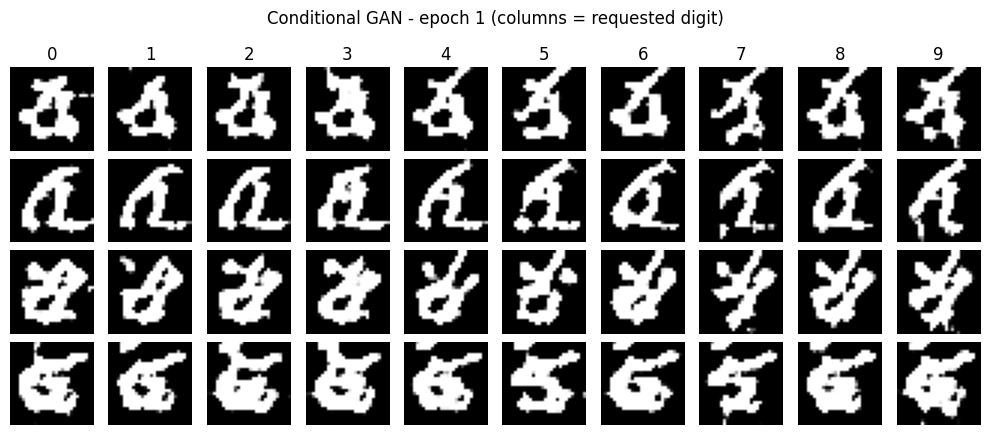

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 47s 35ms/step - d_loss: 0.4408 - g_loss: 1.4485
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.4851 - g_loss: 1.3334
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.3436 - g_loss: 1.7566
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.2068 - g_loss: 2.8950
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6395 - g_loss: 0.9933
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6432 - g_loss: 0.9306
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6671 - g_loss: 0.8422
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6732 - g_loss: 0.8165
Epoch 9/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6725 - g_loss: 0.7887
Epoch 10/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - d_loss: 0.6797 - g_loss: 0.7739

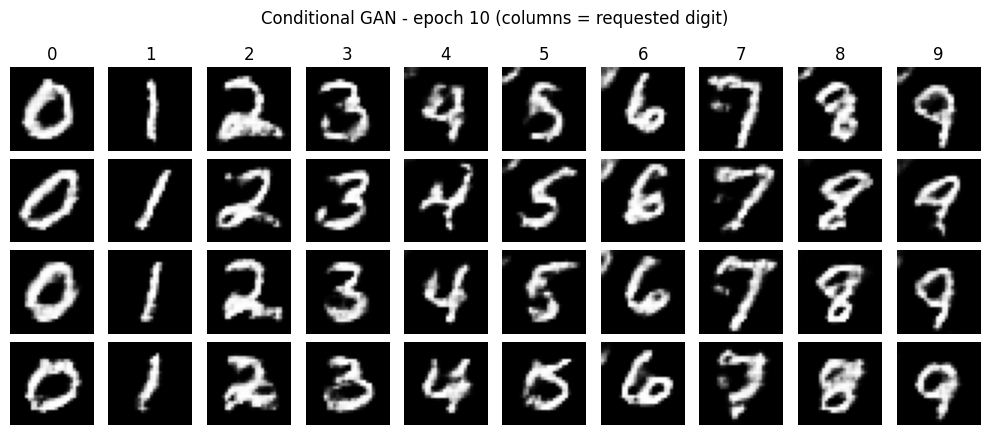

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - d_loss: 0.6811 - g_loss: 0.7677
Epoch 11/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6818 - g_loss: 0.7632
Epoch 12/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6821 - g_loss: 0.7541
Epoch 13/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6798 - g_loss: 0.7532
Epoch 14/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6775 - g_loss: 0.7576
Epoch 15/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6784 - g_loss: 0.7517
Epoch 16/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6731 - g_loss: 0.7627
Epoch 17/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6701 - g_loss: 0.7748
Epoch 18/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - d_loss: 0.6660 - g_loss: 0.7725
Epoch 19/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - d_loss: 0.6624 - g_loss: 0.7758
Epoch 20/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - d_loss: 0.6655 - g_loss: 0.7797

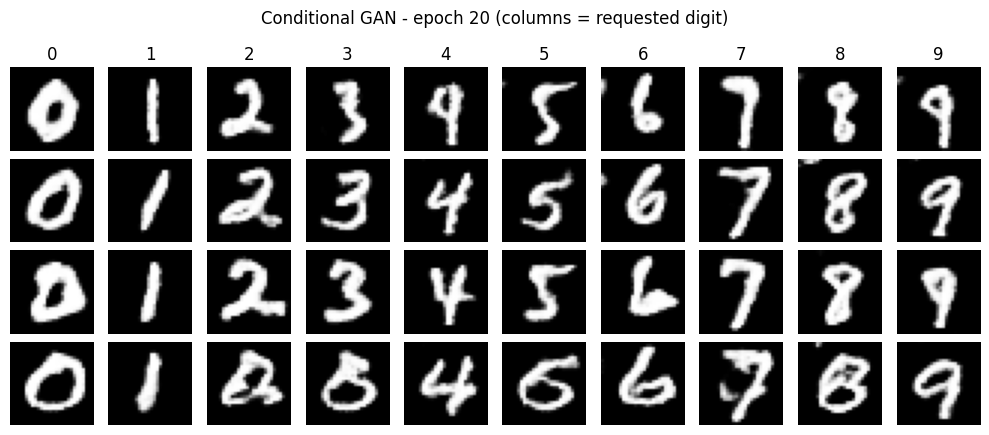

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - d_loss: 0.6588 - g_loss: 0.7906
Conditional GAN training time: 611s


In [37]:
# Fixed noise: 4 rows x 10 digits
c_fixed_noise = np.repeat(np.random.RandomState(42).normal(size=(4, c_latent_dim)), 10, axis=0).astype("float32")
c_fixed_labels = keras.utils.to_categorical(np.tile(np.arange(10), 4), num_classes).astype("float32")

def show_cgan_grid(generator, title, fname):
    imgs = generator.predict(np.concatenate([c_fixed_noise, c_fixed_labels], axis=1), verbose=0)
    fig, axes = plt.subplots(4, 10, figsize=(10, 4.4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i, :, :, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
        if i < 10: ax.set_title(str(i))
    plt.suptitle(title); plt.tight_layout(); plt.savefig(fname); plt.show()

class StageSamples(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        ep = epoch + 1
        if ep in (1, CGAN_EPOCHS // 2, CGAN_EPOCHS):
            show_cgan_grid(self.model.generator, f"Conditional GAN - epoch {ep} (columns = requested digit)", f"cgan_epoch_{ep:03d}.png")

cond_gan = ConditionalGAN(discriminator=cgan_discriminator, generator=cgan_generator, latent_dim=c_latent_dim)
cond_gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

t0 = time.time()
cgan_history = cond_gan.fit(c_dataset, epochs=CGAN_EPOCHS, callbacks=[StageSamples()])
print(f"Conditional GAN training time: {time.time() - t0:.0f}s")

### Conditional GAN loss curves

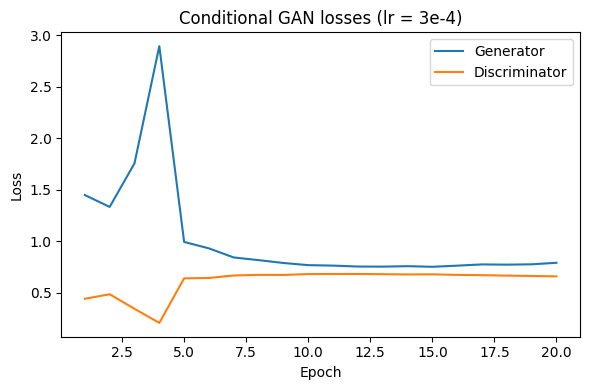

epoch 1: G=1.448  D=0.441
epoch 10: G=0.768  D=0.681
epoch 20: G=0.791  D=0.659


In [38]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, CGAN_EPOCHS + 1), cgan_history.history["g_loss"], label="Generator")
plt.plot(range(1, CGAN_EPOCHS + 1), cgan_history.history["d_loss"], label="Discriminator")
plt.title("Conditional GAN losses (lr = 3e-4)"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("cgan_loss.png"); plt.show()
for e in (1, CGAN_EPOCHS // 2, CGAN_EPOCHS):
    print(f"epoch {e}: G={cgan_history.history['g_loss'][e-1]:.3f}  D={cgan_history.history['d_loss'][e-1]:.3f}")

### Generating digits on demand

Each **row** below is one requested digit (0–9), with 10 different random noise vectors. Within a row, the class stays the same and the noise changes only the handwriting style (thickness, slant, shape).

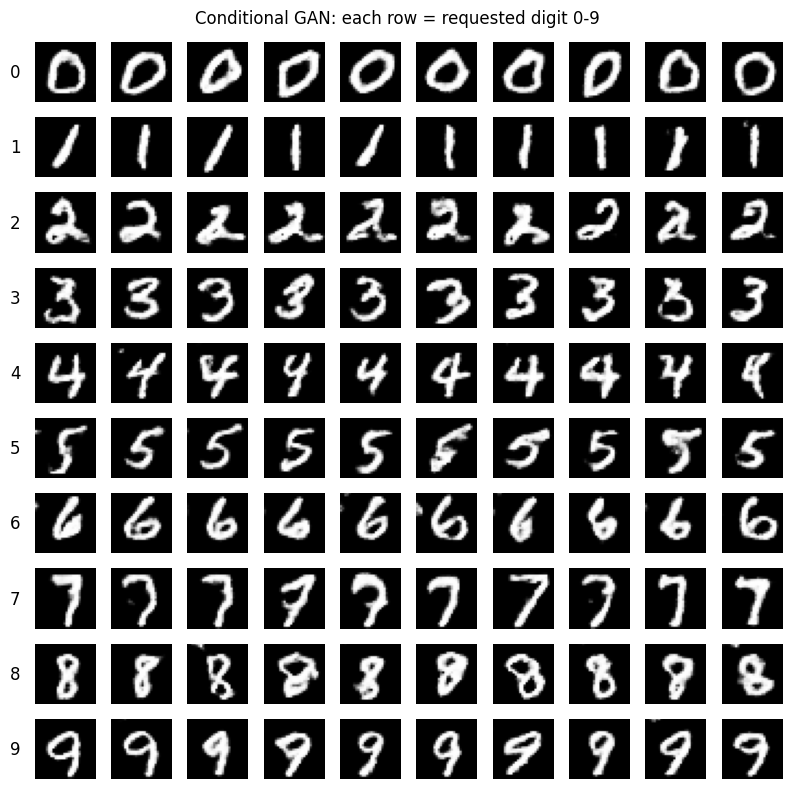

In [39]:
z = np.random.normal(size=(100, c_latent_dim)).astype("float32")
lab = keras.utils.to_categorical(np.repeat(np.arange(10), 10), num_classes).astype("float32")
imgs = cond_gan.generator.predict(np.concatenate([z, lab], axis=1), verbose=0)

fig, axes = plt.subplots(10, 10, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, :, :, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
for d in range(10):
    axes[d, 0].text(-12, 14, str(d), fontsize=12, va="center")
plt.suptitle("Conditional GAN: each row = requested digit 0-9"); plt.tight_layout()
plt.savefig("cgan_digits_on_demand.png"); plt.show()

### Interpolating between two classes

The noise is kept fixed and the label is moved smoothly from one digit to another (here 2 → 6). The generator morphs one digit into the other, which shows that the label input controls the digit's identity.

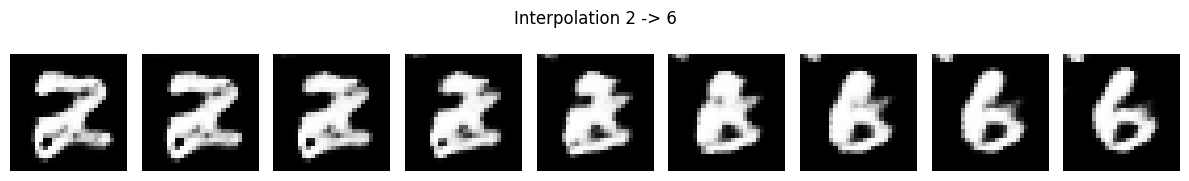

In [40]:
num_interpolation = 9
interp_noise = np.repeat(np.random.normal(size=(1, c_latent_dim)), num_interpolation, axis=0).astype("float32")

def interpolate_class(first_number, second_number):
    a = keras.utils.to_categorical([first_number], num_classes).astype("float32")
    b = keras.utils.to_categorical([second_number], num_classes).astype("float32")
    w = np.linspace(0, 1, num_interpolation)[:, None].astype("float32")
    labels = a * (1 - w) + b * w
    return cond_gan.generator.predict(np.concatenate([interp_noise, labels], axis=1), verbose=0)

start_class, end_class = 2, 6
interp = interpolate_class(start_class, end_class)

fig, axes = plt.subplots(1, num_interpolation, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(interp[i, :, :, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
plt.suptitle(f"Interpolation {start_class} -> {end_class}"); plt.tight_layout()
plt.savefig("cgan_interpolation.png"); plt.show()

### DCGAN vs Conditional GAN

| | DCGAN (Parts 1–4) | Conditional GAN (Part 5) |
|---|---|---|
| Generator input | Noise only (100) | Noise (128) + one-hot label (10) |
| Discriminator input | Image (28×28×1) | Image + label maps (28×28×11) |
| Discriminator question | "Is this image real?" | "Is this a real image **of this digit**?" |
| Control over output | None: random digit | Choose any digit 0–9 |
| Training data | 60,000 train images | 70,000 train + test images with labels |
| Optimizer / epochs | Adam 1e-4, 50 epochs (batch 256) | Adam 3e-4, 20 epochs (batch 64) |
| Output activation / scale | tanh, [-1, 1] | sigmoid, [0, 1] |

**Result.**
- **Conditioning worked.** In the final 10×10 grid, every row shows the requested digit (0–9) in all 10 samples. The noise only changes the handwriting style (slant, thickness, loop shape), never the digit's identity.
- **How it learned.** At **epoch 1**, every column in a row looks almost the same: the output depended only on the noise, and the label was still being ignored. The images were also blocky white blobs. By **epoch 10**, each column already shows the correct digit, and by **epoch 20** the digits are clean and readable.
- **Compared with the DCGAN**, the cGAN's 20-epoch digits are sharper and much more consistent than the DCGAN's 50-epoch samples, where several images were malformed or blended two digits. The label gives the generator extra information, which makes its job easier. (The models also differ in architecture, learning rate, batch size and data size, so this is not a perfectly controlled comparison.)
- **Losses.** The generator loss spiked early (≈2.9 at epoch 4, when the discriminator loss dropped to ≈0.2). After that, both losses settled and stayed very stable from about epoch 7 onward (G ≈ 0.77–0.79, D ≈ 0.66–0.68). This is noticeably smoother than the DCGAN, and especially smoother than the lr = 1e-3 run.
- **Interpolation.** Moving the label from 2 to 6 with fixed noise smoothly morphs the 2 into a 6, which confirms that the label input controls which digit is drawn.
- **Training time:** 611 s for 20 epochs (70,000 images, batch size 64).

**Takeaway.** Conditioning on labels turns the GAN from a random-digit generator into a **controllable** one. This is useful, for example, for generating extra samples of an under-represented class. The trade-off is that it needs labelled data, and the discriminator becomes a stricter critic because it must also check that the image matches the label.